# Reanalysis Heiser et al.
To validate the findings from our MIBI study, we explore spatial pattern in the data generated by [Heiser et al. (2023)](https://www.sciencedirect.com/science/article/pii/S0092867423012229).  
Input data was obtained from [pre-processed spot-level data](https://osf.io/hftq2/) following the [notebook provided to summarize spatial transcriptomics data](https://github.com/Ken-Lau-Lab/spatial_CRC_atlas/blob/main/step5/ST_summaries.ipynb) (the object `a_comb` was exported).

In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
from plotnine import *
import decoupler as dc
from matplotlib import pyplot as plt
from scipy.stats import spearmanr

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# Load data
a_comb = sc.read_h5ad("./data/Heiser_ST_combined.h5ad")
# Select cancer spots
cancer_spots = a_comb[a_comb.obs['Tumor Grade'].isin(['G1', 'G2', 'G3'])].copy()
print(cancer_spots.obs['Tumor Grade'].value_counts())

Tumor Grade
G2    65294
G3    27775
G1    19648
Name: count, dtype: int64


In [3]:
# Compute signature totals for all cancer spots
cancer_spots.obs['CRC_tot'] = cancer_spots.obs['CRC1'] + cancer_spots.obs['CRC2'] + cancer_spots.obs['CRC3'] + cancer_spots.obs['CRC4']
cancer_spots.obs['FIB_tot'] = cancer_spots.obs['FIB1'] + cancer_spots.obs['FIB2'] + cancer_spots.obs['FIB3'] + cancer_spots.obs['FIB4']
cancer_spots.obs['IMMU_tot'] = cancer_spots.obs['MYE1'] + cancer_spots.obs['MYE2'] + cancer_spots.obs['MYE3'] + cancer_spots.obs['MYE4'] + \
    cancer_spots.obs['MYE5'] + cancer_spots.obs['TL1'] + cancer_spots.obs['TL2'] + cancer_spots.obs['TL3'] + cancer_spots.obs['BL1'] + cancer_spots.obs['BL2']


In [6]:
# Compute signature for additional metabolic pathways
hallmark = dc.op.hallmark(organism="human")
hallmark = hallmark.loc[hallmark.source.isin(["GLYCOLYSIS",
                                              "FATTY_ACID_METABOLISM",
                                              "OXIDATIVE_PHOSPHORYLATION"]),:]

# Run msigdb analysis
msig_acts, msig_padj = dc.mt.ulm(data=pd.DataFrame(
                                                cancer_spots.X,
                                                index=cancer_spots.obs_names,
                                                columns=cancer_spots.var_names), 
                                        net=hallmark)

msig_acts.head()

,FATTY_ACID_METABOLISM,GLYCOLYSIS,OXIDATIVE_PHOSPHORYLATION
AAACAGCTTTCAGAAG-1-7319_4_HTA11_01938,1.834791,1.996157,2.474631
AAACCCGAACGAAATC-1-7319_4_HTA11_01938,0.426977,0.225407,1.074724
AAACCGGAAATGTTAA-1-7319_4_HTA11_01938,1.283132,1.193133,2.964138
AAACCGGGTAGGTACC-1-7319_4_HTA11_01938,0.431889,0.536064,0.928241
AAACCGTTCGTCCAGG-1-7319_4_HTA11_01938,1.515695,1.438630,2.790462


In [15]:
from scipy.stats import spearmanr


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 3.5 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ./figures/extrafig/proliferation_vs_glycolysis_visium.pdf


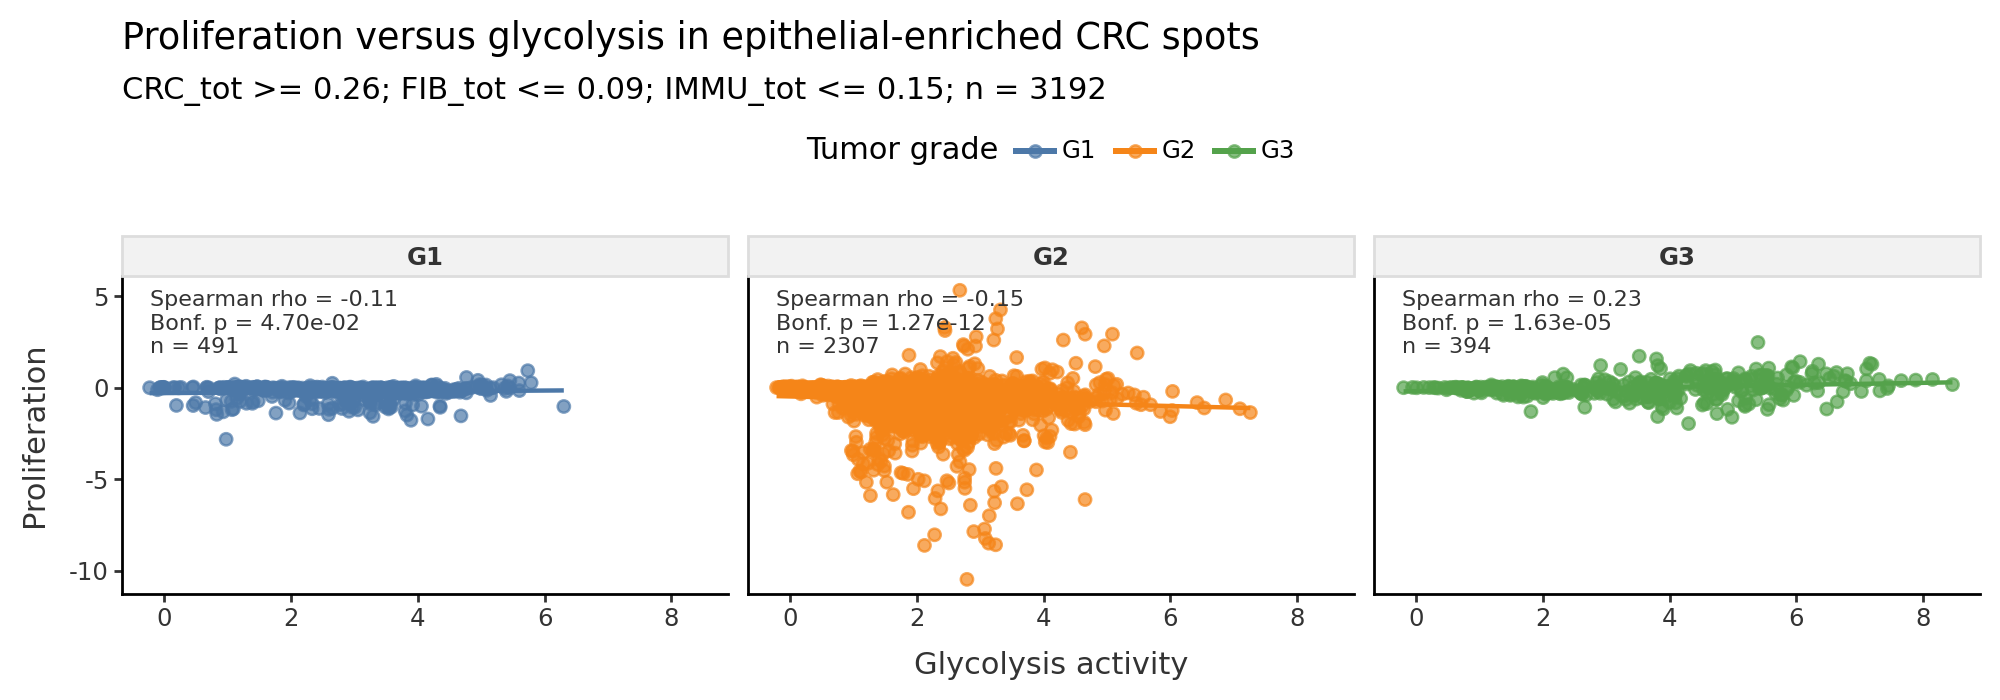

In [19]:
"""
Plot Proliferation vs GLYCOLYSIS
When CRC_tot is high, FIB_tot is low, and IMMU_tot is low
Stratify by Tumor Grade
"""

# Restrict to spots that received pathway scores from decoupler
plot_df = cancer_spots.obs.loc[
    msig_acts.index, ["CRC_tot", "FIB_tot", "IMMU_tot", "Proliferation", "Tumor Grade"]
].copy()
plot_df["GLYCOLYSIS"] = msig_acts["GLYCOLYSIS"].values

# Rename for plotnine faceting
plot_df = plot_df.rename(columns={"Tumor Grade": "Tumor_Grade"})

# Top 20% CRC_tot, bottom 20% FIB_tot and IMMU_tot
crc_cutoff = plot_df["CRC_tot"].quantile(0.80)
fib_cutoff = plot_df["FIB_tot"].quantile(0.20)
immu_cutoff = plot_df["IMMU_tot"].quantile(0.20)

plot_df = plot_df.loc[
    (plot_df["CRC_tot"] >= crc_cutoff)
    & (plot_df["FIB_tot"] <= fib_cutoff)
    & (plot_df["IMMU_tot"] <= immu_cutoff)
].copy()

plot_df["Tumor_Grade"] = pd.Categorical(
    plot_df["Tumor_Grade"],
    categories=["G1", "G2", "G3"],
    ordered=True,
)

# Spearman correlation per grade with Bonferroni correction
label_x = plot_df["GLYCOLYSIS"].min()
label_y = plot_df["Proliferation"].max()
n_grades = plot_df["Tumor_Grade"].nunique()

corr_rows = []
for grade, df_grade in plot_df.groupby("Tumor_Grade", observed=True):
    df_grade = df_grade.dropna(subset=["GLYCOLYSIS", "Proliferation"])

    if len(df_grade) >= 3:
        rho, pval = spearmanr(df_grade["GLYCOLYSIS"], df_grade["Proliferation"])
        pval_adj = min(pval * n_grades, 1.0)
        label = f"Spearman rho = {rho:.2f}\nBonf. p = {pval_adj:.2e}\nn = {len(df_grade)}"
    else:
        label = f"Spearman rho = NA\nBonf. p = NA\nn = {len(df_grade)}"

    corr_rows.append(
        {
            "Tumor_Grade": grade,
            "x": label_x,
            "y": label_y,
            "label": label,
        }
    )

corr_df = pd.DataFrame(corr_rows)

gp = (
    ggplot(plot_df, aes(x="GLYCOLYSIS", y="Proliferation", color="Tumor_Grade"))
    + geom_point(alpha=0.7, size=2)
    + geom_smooth(method="lm", se=False, size=0.9)
    + geom_text(
        data=corr_df,
        mapping=aes(x="x", y="y", label="label"),
        inherit_aes=False,
        ha="left",
        va="top",
        size=8,
        color="#333333",
    )
    + facet_wrap("~Tumor_Grade", nrow=1)
    + scale_color_manual(values=["#4C78A8", "#F58518", "#54A24B"])
    + theme_classic()
    + theme(
        figure_size=(10, 3.5),
        legend_position="top",
        strip_background=element_rect(fill="#F2F2F2", color="#DDDDDD"),
        strip_text=element_text(weight="bold", color="#333333"),
        axis_text=element_text(color="#333333"),
        axis_title=element_text(color="#333333"),
    )
    + labs(
        title="Proliferation versus glycolysis in epithelial-enriched CRC spots",
        subtitle=(
            f"CRC_tot >= {crc_cutoff:.2f}; "
            f"FIB_tot <= {fib_cutoff:.2f}; "
            f"IMMU_tot <= {immu_cutoff:.2f}; "
            f"n = {len(plot_df)}"
        ),
        x="Glycolysis activity",
        y="Proliferation",
        color="Tumor grade",
    )
)

ggsave(gp, "./figures/extrafig/proliferation_vs_glycolysis_visium.pdf",
       width=10, height=3.5)
gp